In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

INTERIM_DIR = Path("../data/interim")

df = pd.read_parquet(INTERIM_DIR / "retail_clean.parquet")

# fix Customer ID dtype (float artifact from earlier NaN handling)
df["Customer ID"] = df["Customer ID"].astype(int).astype(str)

print(df.shape)
df.head()

(824293, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,False


In [6]:
purchases = df[~df["is_cancellation"]].copy()
cancellations = df[df["is_cancellation"]].copy()

print("Purchase rows:", len(purchases))
print("Cancellation rows:", len(cancellations))

Purchase rows: 805549
Cancellation rows: 18744


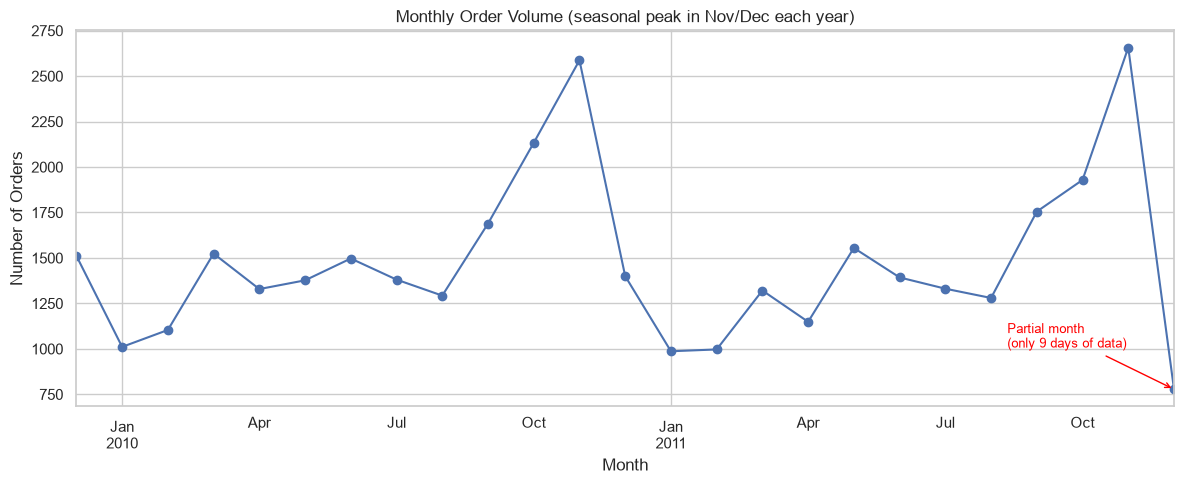

In [11]:
monthly_orders = (
    purchases
    .drop_duplicates(subset="Invoice")  # one row per invoice for order-level counting
    .set_index("InvoiceDate")
    .resample("ME")
    .size()
)

plt.figure(figsize=(12, 5))
monthly_orders.plot(kind="line", marker="o")

# annotate the partial month
plt.axvspan(monthly_orders.index[-1] - pd.Timedelta(days=15), monthly_orders.index[-1] + pd.Timedelta(days=15),
            color="red", alpha=0.1)
plt.annotate("Partial month\n(only 9 days of data)",
             xy=(monthly_orders.index[-1], monthly_orders.iloc[-1]),
             xytext=(-120, 30), textcoords="offset points",
             arrowprops=dict(arrowstyle="->", color="red"),
             color="red", fontsize=9)

plt.title("Monthly Order Volume (seasonal peak in Nov/Dec each year)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [9]:
orders_per_customer = (
    purchases.groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index(name="n_orders")
)

orders_per_customer["n_orders"].describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: n_orders, dtype: float64

In [10]:
one_time = (orders_per_customer["n_orders"] == 1).sum()
repeat = (orders_per_customer["n_orders"] > 1).sum()
total = len(orders_per_customer)

print(f"One-time buyers: {one_time} ({one_time/total:.1%})")
print(f"Repeat buyers:   {repeat} ({repeat/total:.1%})")

One-time buyers: 1623 (27.6%)
Repeat buyers:   4255 (72.4%)


In [12]:
reference_date = df["InvoiceDate"].max()
print("Reference date for recency calculations:", reference_date)

Reference date for recency calculations: 2011-12-09 12:50:00


In [13]:
# get one row per invoice (order-level), sorted by customer and date
order_dates = (
    purchases
    .drop_duplicates(subset="Invoice")
    [["Customer ID", "InvoiceDate"]]
    .sort_values(["Customer ID", "InvoiceDate"])
)

# compute days since previous order, within each customer
order_dates["days_since_prev_order"] = (
    order_dates.groupby("Customer ID")["InvoiceDate"]
    .diff()
    .dt.days
)

# drop the first order per customer (no previous order to compare to)
gaps = order_dates["days_since_prev_order"].dropna()

gaps.describe()

count    31091.000000
mean        51.239426
std         75.754392
min          0.000000
25%          6.000000
50%         24.000000
75%         61.000000
max        714.000000
Name: days_since_prev_order, dtype: float64

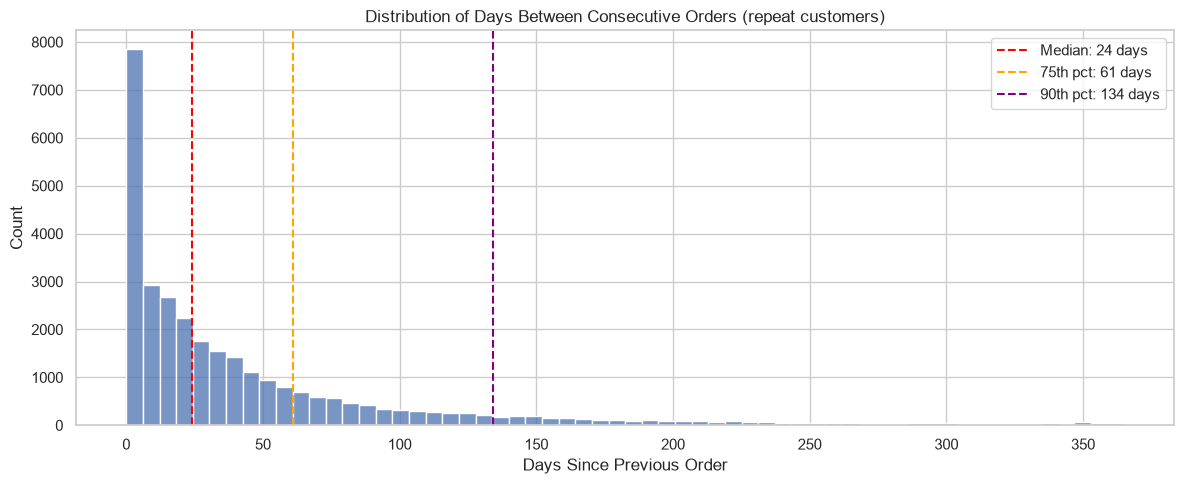

In [14]:
plt.figure(figsize=(12, 5))
sns.histplot(gaps[gaps <= 365], bins=60, kde=False)  # cap at 1 year for readability
plt.axvline(gaps.median(), color="red", linestyle="--", label=f"Median: {gaps.median():.0f} days")
plt.axvline(gaps.quantile(0.75), color="orange", linestyle="--", label=f"75th pct: {gaps.quantile(0.75):.0f} days")
plt.axvline(gaps.quantile(0.90), color="purple", linestyle="--", label=f"90th pct: {gaps.quantile(0.90):.0f} days")
plt.title("Distribution of Days Between Consecutive Orders (repeat customers)")
plt.xlabel("Days Since Previous Order")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
for pct in [0.5, 0.6, 0.7, 0.75, 0.8, 0.9, 0.95]:
    print(f"{int(pct*100)}th percentile: {gaps.quantile(pct):.0f} days")

50th percentile: 24 days
60th percentile: 35 days
70th percentile: 50 days
75th percentile: 61 days
80th percentile: 76 days
90th percentile: 134 days
95th percentile: 206 days


In [20]:
reference_date = df["InvoiceDate"].max()
CHURN_WINDOW_DAYS = 75

# recency per customer: days since their most recent purchase
customer_recency = (
    purchases.groupby("Customer ID")["InvoiceDate"]
    .max()
    .reset_index(name="last_purchase_date")
)

customer_recency["recency_days"] = (reference_date - customer_recency["last_purchase_date"]).dt.days
customer_recency["is_churned"] = customer_recency["recency_days"] > CHURN_WINDOW_DAYS

customer_recency["is_churned"].value_counts(normalize=True)

is_churned
True     0.53998
False    0.46002
Name: proportion, dtype: float64